Heart Disease Prediction

 Problem Statement:
-Predict whether a patient is at risk of heart disease using medical attributes.

Goal:
-Build and evaluate a binary classification model using Logistic Regression.

In [25]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.preprocessing import StandardScaler

In [26]:
# Load the dataset

df = pd.read_csv("heart.csv")

# Check dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# Show first 5 rows
df.head()

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [29]:
# Remove non-medical / leakage columns

# Drop only if columns exist
df = df.drop(columns=["id", "dataset"], errors="ignore")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [30]:
# Check missing values
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [31]:
# Fill numerical columns with mean
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode (safe method)
cat_cols = df.select_dtypes(include=["object", "bool"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_13936\2806485866.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "bool"]).columns


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [32]:
# Basic dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    str    
 2   cp        920 non-null    str    
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    object 
 6   restecg   920 non-null    str    
 7   thalch    920 non-null    float64
 8   exang     920 non-null    object 
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    str    
 11  ca        920 non-null    float64
 12  thal      920 non-null    str    
 13  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(2), str(5)
memory usage: 100.8+ KB


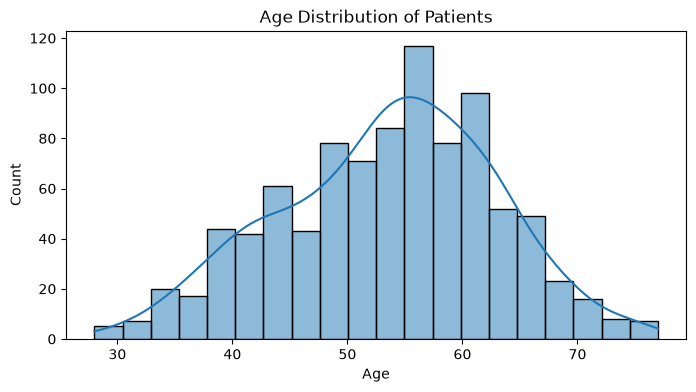


--- AGE GRAPH SUMMARY ---
Min age: 28
Max age: 77
Mean age: 53.51086956521739
Median age: 54.0
Most common age range (approx):
(27.95, 37.8]     49
(37.8, 47.6]     190
(47.6, 57.4]     350
(57.4, 67.2]     277
(67.2, 77.0]      54
Name: count, dtype: int64


In [33]:
# Age distribution + auto-summary stats (for sharing)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ---- summary stats for interpretation ----
print("\n--- AGE GRAPH SUMMARY ---")
print("Min age:", df["age"].min())
print("Max age:", df["age"].max())
print("Mean age:", df["age"].mean())
print("Median age:", df["age"].median())
print("Most common age range (approx):")
print(df["age"].value_counts(bins=5).sort_index())

The dataset is dominated by middle-aged individuals, with the majority of patients between 47 and 67 years. This suggests age may be a strong predictive factor for heart disease risk

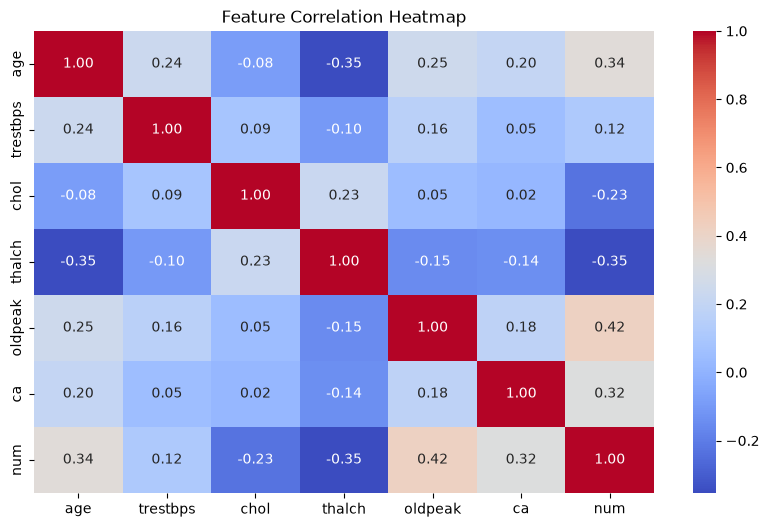


--- CORRELATION WITH TARGET (num) ---
num         1.000000
oldpeak     0.421907
age         0.339596
ca          0.321404
trestbps    0.116225
chol       -0.228238
thalch     -0.351055
Name: num, dtype: float64

--- STRONG RELATIONS (> 0.3 or < -0.3) ---
age        0.339596
thalch    -0.351055
oldpeak    0.421907
ca         0.321404
num        1.000000
Name: num, dtype: float64


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = df.corr(numeric_only=True)

# --- GRAPH ---
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# --- TEXT OUTPUT FOR UNDERSTANDING ---
print("\n--- CORRELATION WITH TARGET (num) ---")
print(corr["num"].sort_values(ascending=False))

print("\n--- STRONG RELATIONS (> 0.3 or < -0.3) ---")
print(corr["num"][(corr["num"] > 0.3) | (corr["num"] < -0.3)])

Correlation analysis shows that oldpeak and age have a positive relationship with heart disease risk, while thalch shows a negative relationship, indicating that higher maximum heart rate is associated with lower risk.

In [35]:
# Convert target into binary classification
# 0 = no disease, 1 = disease (any level > 0)

df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# Check new distribution
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [36]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# columns with text
cat_cols = df_encoded.select_dtypes(include=["object", "bool", "str"]).columns

le = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


In [37]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("num", axis=1)
y = df_encoded["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(736, 13) (184, 13)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling successful")

Scaling successful


Model Training (Logistic Regression)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.7717391304347826


In [40]:
# Check model performance on both training and test data
# This helps us detect overfitting or underfitting

# Accuracy on training data
train_acc = model.score(X_train_scaled, y_train)

# Accuracy on test data (unseen data)
test_acc = model.score(X_test_scaled, y_test)

# Print results
print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.8274456521739131
Test Accuracy: 0.7717391304347826


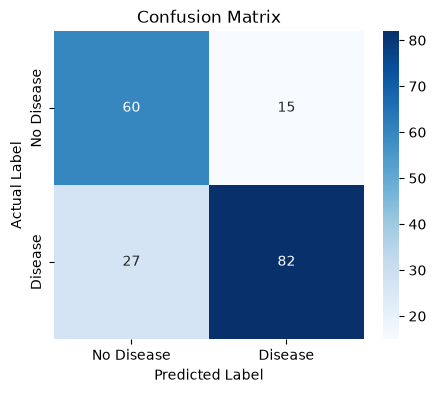


Confusion Matrix:
[[60 15]
 [27 82]]


In [41]:
# Confusion Matrix - shows correct vs incorrect predictions

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions (already done earlier, but kept here for clarity)
y_pred = model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap for better visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Print raw matrix
print("\nConfusion Matrix:")
print(cm)

# Interpretation guide:
# TN = correctly predicted no disease
# TP = correctly predicted disease
# FP = false alarm (predicted disease but actually no disease)
# FN = missed disease (predicted no disease but actually disease)

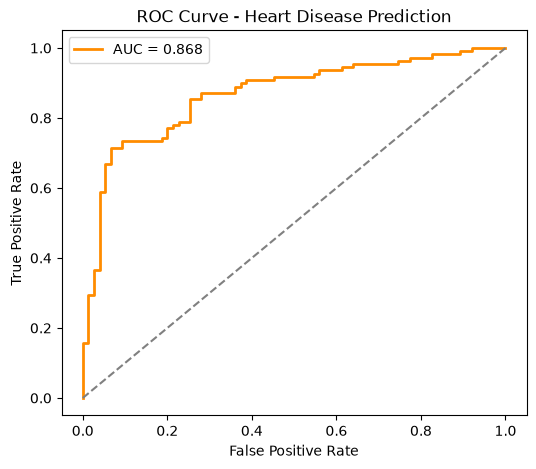

AUC Score: 0.8680122324159022


In [42]:
# ROC Curve - evaluates how well the model separates classes

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores for the positive class (Disease = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend()
plt.show()

# Print AUC value
print("AUC Score:", auc)

# Interpretation:
# AUC closer to 1 = better model
# 0.5 = random guessing

The AUC score of 0.868 indicates good discriminative ability, meaning the model can effectively distinguish between patients with and without heart disease.

In [43]:
# Feature importance using Logistic Regression coefficients

import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

# Sort by absolute importance
feature_importance["Abs_Importance"] = np.abs(feature_importance["Importance"])
feature_importance = feature_importance.sort_values("Abs_Importance", ascending=False)

print(feature_importance[["Feature", "Importance"]])

     Feature  Importance
9    oldpeak    0.699543
1        sex    0.624345
11        ca    0.622031
2         cp   -0.598092
8      exang    0.528593
4       chol   -0.500451
7     thalch   -0.301185
12      thal    0.194886
5        fbs    0.168084
0        age    0.151587
10     slope   -0.107228
3   trestbps    0.033704
6    restecg    0.017194


FINAL EXPLANATION AND INSIGHTS:
    The model achieved a training accuracy of about 0.83 and a test accuracy of about 0.77, showing a small gap between them, which suggests only mild overfitting and generally good generalization. The AUC score of 0.868 indicates good discriminative ability, meaning the model can reliably distinguish between patients with and without heart disease. The confusion matrix shows a balanced performance with a reasonable number of correct predictions in both classes, though some misclassifications still exist. Feature importance analysis reveals that oldpeak, sex, ca, cp, exang, and chol are the most influential predictors, while features like trestbps and restecg contribute very little.

The dataset contains 920 patient records with a mix of clinical and demographic features for heart disease prediction. It had noticeable missing values in several columns, which were handled during preprocessing to make the data usable for modeling.
